# Master Runner: Generate slide assets + exported artifacts (IDI GLM vs FFNN)

This is an **orchestrator** notebook that generates a complete evidence pack into a versioned run folder.
It does not replace your modular notebooks; it is a convenience runner for regenerating slide assets consistently.

Outputs (in `RUN_DIR`):
- sanity_table.csv, time_split_timeline.png, incidence_by_month.png, severity_log1p_hist.png
- glm_test_exposure_scored.csv, glm_test_claims_scored.csv
- ffnn_test_exposure_scored.csv, ffnn_test_claims_scored.csv
- comparison_scorecard.csv
- run_metadata.json (versions, seed, split cutoff)

Date created: 2026-06-06


In [ ]:
# Common setup

import os
import sys
import platform
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.preprocessing import OneHotEncoder

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

pd.set_option("display.max_columns", 200)
np.set_printoptions(suppress=True)

def make_ohe_dense(drop=None):
    """Dense one-hot encoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, drop=drop)

def make_ohe_sparse(drop=None):
    """Sparse one-hot encoder compatible across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, drop=drop)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True, drop=drop)

def env_fingerprint():
    import sklearn
    fp = {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
    }
    try:
        import tensorflow as tf
        fp["tensorflow"] = tf.__version__
    except Exception:
        fp["tensorflow"] = None
    return fp

In [ ]:
# Paths

PROJECT_ROOT = Path("C:/Users/ca/OneDrive/Documents/@ CA/@ PROJECTS/FFNNs/IDS 2026")

EXPOSURE_CSV = f"{PROJECT_ROOT}/data/raw/idi_exposure_synth_v1.csv"
CLAIMS_CSV   = f"{PROJECT_ROOT}/data/raw/idi_claims_synth_v1.csv"

OUT_DIR = "outputs_figures"
os.makedirs(OUT_DIR, exist_ok=True)

EXPOSURE_CSV, CLAIMS_CSV, OUT_DIR

('C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_exposure_synth_v1.csv',
 'C:\\Users\\ca\\OneDrive\\Documents\\@ CA\\@ PROJECTS\\FFNNs\\IDS 2026/data/raw/idi_claims_synth_v1.csv',
 'outputs_figures')

In [ ]:
# Run metadata and versioned output folder

RUN_ID = time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(OUT_DIR, f"run_{RUN_ID}")
os.makedirs(RUN_DIR, exist_ok=True)

SEED = 7
np.random.seed(SEED)

meta = {
    "run_id": RUN_ID,
    "seed": SEED,
    "created_date": time.strftime("%Y-%m-%d"),
    "env": env_fingerprint(),
}
meta_path = os.path.join(RUN_DIR, "run_metadata.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

meta_path

'outputs_figures\\run_20260606_155738\\run_metadata.json'

In [ ]:
# Load data

expo_df = pd.read_csv(EXPOSURE_CSV, parse_dates=["month_start"])
claims_df = pd.read_csv(CLAIMS_CSV, parse_dates=["month_start"])

for c in ["life_id","month_start","exposure_months","onset","claim_id"]:
    assert c in expo_df.columns, f"Missing in exposure: {c}"
for c in ["claim_id","month_start","total_paid_ultimate","life_id"]:
    assert c in claims_df.columns, f"Missing in claims: {c}"

print("Exposure rows:", len(expo_df), "| Claims rows:", len(claims_df))
print("Monthly onset rate:", round(float(expo_df['onset'].mean()), 6))
print("Mean claim cost (CHF):", f"{claims_df['total_paid_ultimate'].mean():,.0f}")

# --- Time split ---
N_TEST_MONTHS = 6
months_sorted = np.sort(expo_df["month_start"].unique())
if len(months_sorted) < N_TEST_MONTHS + 1:
    raise ValueError("Not enough months for chosen test window.")

cutoff = months_sorted[-N_TEST_MONTHS]

train_expo = expo_df[expo_df["month_start"] < cutoff].copy()
test_expo  = expo_df[expo_df["month_start"] >= cutoff].copy()
train_claims = claims_df[claims_df["month_start"] < cutoff].copy()
test_claims  = claims_df[claims_df["month_start"] >= cutoff].copy()

print("Test starts:", pd.to_datetime(cutoff).date())
print("Train exposure:", len(train_expo), " Test exposure:", len(test_expo))
print("Train claims:", len(train_claims), " Test claims:", len(test_claims))
assert len(train_claims) > 0 and len(test_claims) > 0, "Train/test claims split is empty."

Exposure rows: 144000 | Claims rows: 1565
Monthly onset rate: 0.010868
Mean claim cost (CHF): 101,625
Test starts: 2023-07-01
Train exposure: 108000  Test exposure: 36000
Train claims: 1181  Test claims: 384


In [ ]:
# Feature set

cat_cols = [
    "region",
    "occ",
    "employer",
    "plan",
    "sex",
    "smoker",
    "bmi_band",
    "salary_band",
    "underwriting_class",
    "elim_period",
    "benefit_period",
    "season"
]

num_cols = [
    "age",
    "chronic_resp_flag",
    "chronic_cardio_flag",
    "prior_claim_flag",
    "cola_flag",
    "monthly_benefit_cap",
    "heat_index_30d",
    "smoke_pm25_30d",
    "flood_flag_30d",
    "compound_heat_smoke",
    "extreme_heat"
]

X_cols = cat_cols + num_cols

missing = [c for c in X_cols if c not in expo_df.columns]
assert not missing, f"Missing features: {missing}"

## Part A — Data profile assets

In [ ]:
summary = {
    "exposure_rows": int(len(expo_df)),
    "claims_rows": int(len(claims_df)),
    "date_min": str(expo_df["month_start"].min().date()),
    "date_max": str(expo_df["month_start"].max().date()),
    "monthly_onset_rate": float(expo_df["onset"].mean()),
    "mean_claim_cost_chf": float(claims_df["total_paid_ultimate"].mean()),
    "p90_claim_cost_chf": float(np.quantile(claims_df["total_paid_ultimate"], 0.90)),
    "test_start": str(pd.to_datetime(cutoff).date()),
    "n_test_months": int(N_TEST_MONTHS),
}
sanity_tbl = pd.DataFrame([summary])
display(sanity_tbl.style.format({
    "monthly_onset_rate": "{:.6f}",
    "mean_claim_cost_chf": "{:,.0f}",
    "p90_claim_cost_chf": "{:,.0f}",
}))

sanity_path = os.path.join(RUN_DIR, "sanity_table.csv")
sanity_tbl.to_csv(sanity_path, index=False)
sanity_path


,exposure_rows,claims_rows,date_min,date_max,monthly_onset_rate,mean_claim_cost_chf,p90_claim_cost_chf,test_start,n_test_months
0,144000,1565,2022-01-01,2023-12-01,0.010868,"101,625","160,396",2023-07-01,6


'outputs_figures\\run_20260606_155738\\sanity_table.csv'

'outputs_figures\\run_20260606_155738\\incidence_by_month.svg'

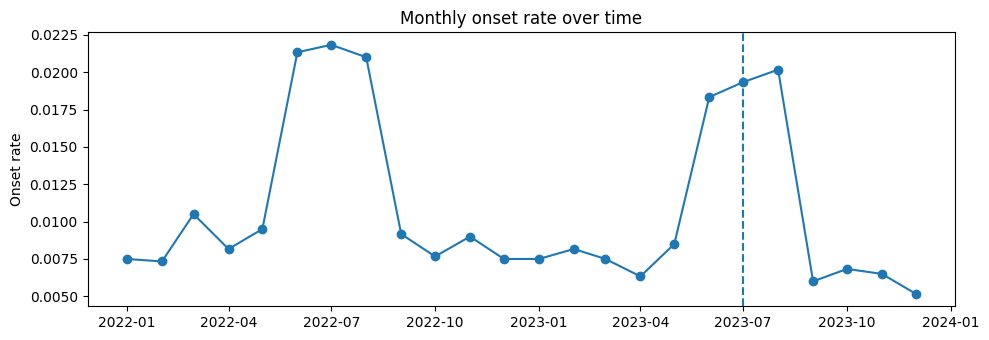

In [ ]:
inc_by_month = expo_df.groupby("month_start")["onset"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(inc_by_month["month_start"], inc_by_month["onset"], marker="o")
ax.axvline(pd.to_datetime(cutoff), linestyle="--")
ax.set_title("Monthly onset rate over time")
ax.set_ylabel("Onset rate")
fig.tight_layout()
p = os.path.join(RUN_DIR, "incidence_by_month.svg")
fig.savefig(p, dpi=300)
p

'outputs_figures\\run_20260606_155738\\severity_log1p_hist.svg'

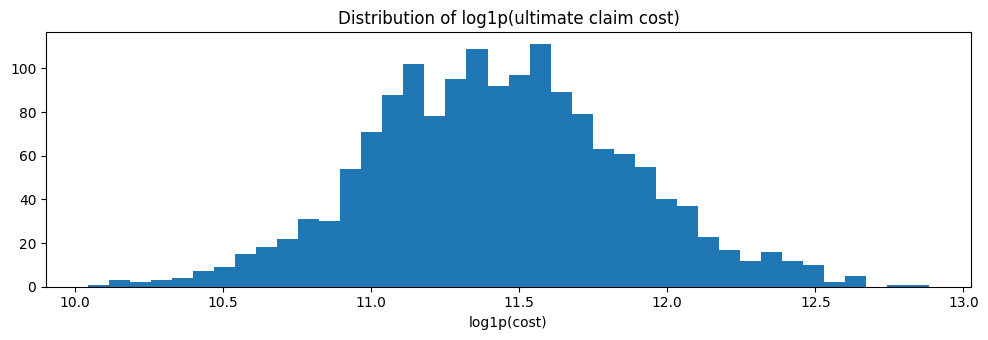

In [ ]:
y_all = claims_df["total_paid_ultimate"].astype(float).values
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(np.log1p(y_all), bins=40)
ax.set_title("Distribution of log1p(ultimate claim cost)")
ax.set_xlabel("log1p(cost)")
fig.tight_layout()
p = os.path.join(RUN_DIR, "severity_log1p_hist.svg")
fig.savefig(p, dpi=300)
p

## Part B — GLM baseline + exports

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, TweedieRegressor

preproc_sparse = ColumnTransformer(
    transformers=[
        ("cat", make_ohe_sparse(), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop",
)

glm_inc = Pipeline(steps=[
    ("prep", preproc_sparse),
    ("scale_all", MaxAbsScaler()),
    ("clf", LogisticRegression(
        solver="saga", penalty="l2", C=1.0, max_iter=2000,
        tol=1e-4, n_jobs=-1, random_state=SEED
    ))
])
glm_inc.fit(train_expo[X_cols], train_expo["onset"].values)
p_glm = glm_inc.predict_proba(test_expo[X_cols])[:, 1]

glm_sev = Pipeline(steps=[
    ("prep", preproc_sparse),
    ("scale_all", MaxAbsScaler()),
    ("twd", TweedieRegressor(power=1.5, alpha=1e-4, link="log", max_iter=1200)),
])
glm_sev.fit(train_claims[X_cols], train_claims["total_paid_ultimate"].values.astype(float))
sev_glm_claims = np.clip(glm_sev.predict(test_claims[X_cols]), 1.0, None)
sev_glm_expo = np.clip(glm_sev.predict(test_expo[X_cols]), 1.0, None)

glm_expo_scored = test_expo[["life_id","month_start","exposure_months","onset","claim_id"]].copy()
glm_expo_scored["p_hat"] = p_glm
glm_expo_scored["sev_hat"] = sev_glm_expo
glm_expo_scored["exp_cost"] = glm_expo_scored["p_hat"] * glm_expo_scored["sev_hat"]

glm_claims_scored = test_claims[["claim_id","life_id","month_start","total_paid_ultimate"]].copy()
glm_claims_scored["sev_hat"] = sev_glm_claims

glm_expo_path = os.path.join(RUN_DIR, "glm_test_exposure_scored.csv")
glm_claims_path = os.path.join(RUN_DIR, "glm_test_claims_scored.csv")
glm_expo_scored.to_csv(glm_expo_path, index=False)
glm_claims_scored.to_csv(glm_claims_path, index=False)

(glm_expo_path, glm_claims_path)


('outputs_figures\\run_20260606_155738\\glm_test_exposure_scored.csv',
 'outputs_figures\\run_20260606_155738\\glm_test_claims_scored.csv')

## Part C — FFNN challenger + exports

In [ ]:

high_id_cols = ["region_id","occ_id","employer_id","plan_id"]
small_cat_cols = ["sex","smoker","bmi_band","salary_band","underwriting_class","elim_period","benefit_period","season"]

preproc_dense = ColumnTransformer(
    transformers=[
        ("cat", make_ohe_dense(), small_cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

Xtr_dense = preproc_dense.fit_transform(train_expo[small_cat_cols + num_cols])
Xte_dense = preproc_dense.transform(test_expo[small_cat_cols + num_cols])
Xtr_ids = train_expo[high_id_cols].values.astype("int32")
Xte_ids = test_expo[high_id_cols].values.astype("int32")

Xtrc_dense = preproc_dense.transform(train_claims[small_cat_cols + num_cols])
Xtec_dense = preproc_dense.transform(test_claims[small_cat_cols + num_cols])
Xtrc_ids = train_claims[high_id_cols].values.astype("int32")
Xtec_ids = test_claims[high_id_cols].values.astype("int32")

ytr_inc = train_expo["onset"].values.astype("float32")
ytr_sev = train_claims["total_paid_ultimate"].values.astype("float32")

dense_dim = Xtr_dense.shape[1]
n_region = int(expo_df["region_id"].max() + 1)
n_occ    = int(expo_df["occ_id"].max() + 1)
n_emp    = int(expo_df["employer_id"].max() + 1)
n_plan   = int(expo_df["plan_id"].max() + 1)

(dense_dim, n_region, n_occ, n_emp, n_plan)

(34, 120, 180, 350, 12)

In [ ]:

tf.random.set_seed(SEED)

EPOCHS_FREQ = 15
EPOCHS_SEV  = 50

def build_freq_model(n_region, n_occ, n_emp, n_plan, dense_dim):
    inp_r = tf.keras.Input((1,), dtype="int32", name="region_id")
    inp_o = tf.keras.Input((1,), dtype="int32", name="occ_id")
    inp_e = tf.keras.Input((1,), dtype="int32", name="employer_id")
    inp_p = tf.keras.Input((1,), dtype="int32", name="plan_id")
    inp_x = tf.keras.Input((dense_dim,), dtype="float32", name="x_dense")
    er = tf.keras.layers.Embedding(n_region, 8)(inp_r)
    eo = tf.keras.layers.Embedding(n_occ, 8)(inp_o)
    ee = tf.keras.layers.Embedding(n_emp, 6)(inp_e)
    ep = tf.keras.layers.Embedding(n_plan, 4)(inp_p)
    z = tf.keras.layers.Concatenate()([tf.keras.layers.Flatten()(er), tf.keras.layers.Flatten()(eo), tf.keras.layers.Flatten()(ee), tf.keras.layers.Flatten()(ep), inp_x])
    z = tf.keras.layers.Dense(64, activation="relu")(z)
    z = tf.keras.layers.Dropout(0.15)(z)
    z = tf.keras.layers.Dense(32, activation="relu")(z)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(z)
    m = tf.keras.Model([inp_r, inp_o, inp_e, inp_p, inp_x], out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m

def build_sev_model(n_region, n_occ, n_emp, n_plan, dense_dim, mu0):
    inp_r = tf.keras.Input((1,), dtype="int32", name="region_id")
    inp_o = tf.keras.Input((1,), dtype="int32", name="occ_id")
    inp_e = tf.keras.Input((1,), dtype="int32", name="employer_id")
    inp_p = tf.keras.Input((1,), dtype="int32", name="plan_id")
    inp_x = tf.keras.Input((dense_dim,), dtype="float32", name="x_dense")
    er = tf.keras.layers.Embedding(n_region, 8)(inp_r)
    eo = tf.keras.layers.Embedding(n_occ, 8)(inp_o)
    ee = tf.keras.layers.Embedding(n_emp, 6)(inp_e)
    ep = tf.keras.layers.Embedding(n_plan, 4)(inp_p)
    z = tf.keras.layers.Concatenate()([tf.keras.layers.Flatten()(er), tf.keras.layers.Flatten()(eo), tf.keras.layers.Flatten()(ee), tf.keras.layers.Flatten()(ep), inp_x])
    z = tf.keras.layers.Dense(64, activation="relu")(z)
    z = tf.keras.layers.Dropout(0.10)(z)
    z = tf.keras.layers.Dense(32, activation="relu")(z)
    out = tf.keras.layers.Dense(1, activation="linear", bias_initializer=tf.keras.initializers.Constant(mu0))(z)
    m = tf.keras.Model([inp_r, inp_o, inp_e, inp_p, inp_x], out)
    m.compile(optimizer=tf.keras.optimizers.Adam(5e-4), loss=tf.keras.losses.Huber(delta=0.25))
    return m

# Frequency
freq = build_freq_model(n_region, n_occ, n_emp, n_plan, dense_dim)
cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)]
freq.fit(
    x={"region_id":Xtr_ids[:,0],"occ_id":Xtr_ids[:,1],"employer_id":Xtr_ids[:,2],"plan_id":Xtr_ids[:,3],"x_dense":Xtr_dense},
    y=ytr_inc, validation_split=0.10, epochs=EPOCHS_FREQ, batch_size=4096, verbose=1, callbacks=cb
)
p_fnn = freq.predict(
    {"region_id":Xte_ids[:,0],"occ_id":Xte_ids[:,1],"employer_id":Xte_ids[:,2],"plan_id":Xte_ids[:,3],"x_dense":Xte_dense},
    batch_size=8192, verbose=0
).reshape(-1)

# Severity
mu0 = float(np.mean(np.log1p(ytr_sev)))
sev_nn = build_sev_model(n_region, n_occ, n_emp, n_plan, dense_dim, mu0)
cb = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
sev_nn.fit(
    x={"region_id":Xtrc_ids[:,0],"occ_id":Xtrc_ids[:,1],"employer_id":Xtrc_ids[:,2],"plan_id":Xtrc_ids[:,3],"x_dense":Xtrc_dense},
    y=np.log1p(ytr_sev), validation_split=0.15, epochs=EPOCHS_SEV, batch_size=2048, verbose=1, callbacks=cb
)

raw_tr = sev_nn.predict(
    {"region_id":Xtrc_ids[:,0],"occ_id":Xtrc_ids[:,1],"employer_id":Xtrc_ids[:,2],"plan_id":Xtrc_ids[:,3],"x_dense":Xtrc_dense},
    batch_size=8192, verbose=0
).reshape(-1)
smear = float(np.mean(np.exp(np.log1p(ytr_sev) - raw_tr)))
smear = max(smear, 1e-6)
pred_tr = np.expm1(raw_tr + np.log(smear))
adj = float(np.mean(ytr_sev) / max(np.mean(pred_tr), 1e-6))

raw_te_claims = sev_nn.predict(
    {"region_id":Xtec_ids[:,0],"occ_id":Xtec_ids[:,1],"employer_id":Xtec_ids[:,2],"plan_id":Xtec_ids[:,3],"x_dense":Xtec_dense},
    batch_size=8192, verbose=0
).reshape(-1)
sev_fnn_claims = np.clip(np.expm1(raw_te_claims + np.log(smear)) * adj, 1.0, None)

raw_te_expo = sev_nn.predict(
    {"region_id":Xte_ids[:,0],"occ_id":Xte_ids[:,1],"employer_id":Xte_ids[:,2],"plan_id":Xte_ids[:,3],"x_dense":Xte_dense},
    batch_size=8192, verbose=0
).reshape(-1)
sev_fnn_expo = np.clip(np.expm1(raw_te_expo + np.log(smear)) * adj, 1.0, None)

# Export
fnn_expo_scored = test_expo[["life_id","month_start","exposure_months","onset","claim_id"]].copy()
fnn_expo_scored["p_hat"] = p_fnn
fnn_expo_scored["sev_hat"] = sev_fnn_expo
fnn_expo_scored["exp_cost"] = fnn_expo_scored["p_hat"] * fnn_expo_scored["sev_hat"]

fnn_claims_scored = test_claims[["claim_id","life_id","month_start","total_paid_ultimate"]].copy()
fnn_claims_scored["sev_hat"] = sev_fnn_claims

fnn_expo_path = os.path.join(RUN_DIR, "ffnn_test_exposure_scored.csv")
fnn_claims_path = os.path.join(RUN_DIR, "ffnn_test_claims_scored.csv")
fnn_expo_scored.to_csv(fnn_expo_path, index=False)
fnn_claims_scored.to_csv(fnn_claims_path, index=False)

(fnn_expo_path, fnn_claims_path)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.4585 - val_loss: 0.1540
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0859 - val_loss: 0.0599
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0634 - val_loss: 0.0591
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0622 - val_loss: 0.0577
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0609 - val_loss: 0.0571
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0606 - val_loss: 0.0567
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0599 - val_loss: 0.0564
Epoch 8/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0596 - val_loss: 0.0561
Epoch 9/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0590 - val_loss: 0.0559
Epoch 10/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0588 - val_loss: 0.0557
Epoch 11/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0581 - val_loss: 0.0557
Epoch 12/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0580 -

('outputs_figures\\run_20260606_155738\\ffnn_test_exposure_scored.csv',
 'outputs_figures\\run_20260606_155738\\ffnn_test_claims_scored.csv')

## Part D — Comparison scorecard

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, mean_absolute_error

def top_decile_capture(y_true, p_hat, frac=0.10):
    k = max(1, int(frac * len(p_hat)))
    idx = np.argsort(p_hat)[-k:]
    return float(y_true[idx].sum() / max(1, y_true.sum()))

y = glm_expo_scored["onset"].values.astype(float)
p_glm = glm_expo_scored["p_hat"].values.astype(float)
p_fnn = fnn_expo_scored["p_hat"].values.astype(float)

inc = dict(
    observed_rate=float(y.mean()),
    glm_mean_p=float(p_glm.mean()),
    fnn_mean_p=float(p_fnn.mean()),
    glm_auc=float(roc_auc_score(y, p_glm)),
    fnn_auc=float(roc_auc_score(y, p_fnn)),
    glm_pr=float(average_precision_score(y, p_glm)),
    fnn_pr=float(average_precision_score(y, p_fnn)),
    glm_brier=float(brier_score_loss(y, p_glm)),
    fnn_brier=float(brier_score_loss(y, p_fnn)),
    glm_lift10=float(top_decile_capture(y, p_glm)),
    fnn_lift10=float(top_decile_capture(y, p_fnn)),
)

y_sev = glm_claims_scored["total_paid_ultimate"].values.astype(float)
sev_glm = glm_claims_scored["sev_hat"].values.astype(float)
sev_fnn = fnn_claims_scored["sev_hat"].values.astype(float)

rmse_log_glm = float(np.sqrt(np.mean((np.log1p(y_sev)-np.log1p(sev_glm))**2)))
rmse_log_fnn = float(np.sqrt(np.mean((np.log1p(y_sev)-np.log1p(sev_fnn))**2)))
q90 = np.quantile(y_sev, 0.90)
tail = y_sev >= q90
tail_mae_glm = float(mean_absolute_error(y_sev[tail], sev_glm[tail]))
tail_mae_fnn = float(mean_absolute_error(y_sev[tail], sev_fnn[tail]))

exp_months = float(glm_expo_scored["exposure_months"].sum())
act_total = float(y_sev.sum())
pp_act = act_total / exp_months

exp_glm = float(glm_expo_scored["exp_cost"].sum())
exp_fnn = float(fnn_expo_scored["exp_cost"].sum())
pp_glm = exp_glm / exp_months
pp_fnn = exp_fnn / exp_months
oe_glm = act_total / max(exp_glm, 1e-12)
oe_fnn = act_total / max(exp_fnn, 1e-12)

pp_fnnInc_glmSev = float(np.sum(p_fnn * glm_expo_scored["sev_hat"].values.astype(float))) / exp_months
pp_glmInc_fnnSev = float(np.sum(p_glm * fnn_expo_scored["sev_hat"].values.astype(float))) / exp_months

comparison = pd.DataFrame([
    {"Layer":"Incidence","Metric":"Observed rate","Actual":inc["observed_rate"],"GLM":inc["glm_mean_p"],"FFNN":inc["fnn_mean_p"],"Notes":"Calibration-in-the-large"},
    {"Layer":"Incidence","Metric":"AUC (ROC)","Actual":np.nan,"GLM":inc["glm_auc"],"FFNN":inc["fnn_auc"],"Notes":"Ranking quality"},
    {"Layer":"Incidence","Metric":"PR-AUC","Actual":np.nan,"GLM":inc["glm_pr"],"FFNN":inc["fnn_pr"],"Notes":"Rare-event ranking"},
    {"Layer":"Incidence","Metric":"Brier (↓)","Actual":np.nan,"GLM":inc["glm_brier"],"FFNN":inc["fnn_brier"],"Notes":"Probability accuracy"},
    {"Layer":"Incidence","Metric":"Lift@10","Actual":np.nan,"GLM":inc["glm_lift10"],"FFNN":inc["fnn_lift10"],"Notes":"Claims captured in top 10%"},
    {"Layer":"Claim cost","Metric":"Mean cost (CHF)","Actual":float(y_sev.mean()),"GLM":float(sev_glm.mean()),"FFNN":float(sev_fnn.mean()),"Notes":"Level check (claims)"},
    {"Layer":"Claim cost","Metric":"MAE (CHF) (↓)","Actual":np.nan,"GLM":float(mean_absolute_error(y_sev, sev_glm)),"FFNN":float(mean_absolute_error(y_sev, sev_fnn)),"Notes":"Overall error"},
    {"Layer":"Claim cost","Metric":"RMSE log1p (↓)","Actual":np.nan,"GLM":rmse_log_glm,"FFNN":rmse_log_fnn,"Notes":"Multiplicative error"},
    {"Layer":"Claim cost","Metric":"Tail MAE P90+ (↓)","Actual":np.nan,"GLM":tail_mae_glm,"FFNN":tail_mae_fnn,"Notes":"Large-loss focus"},
    {"Layer":"Aggregate","Metric":"Pure premium (CHF/exp-month)","Actual":pp_act,"GLM":pp_glm,"FFNN":pp_fnn,"Notes":"p×mu over exposure"},
    {"Layer":"Aggregate","Metric":"O/E (Actual ÷ Expected)","Actual":1.0,"GLM":oe_glm,"FFNN":oe_fnn,"Notes":"Ideal ≈ 1"},
    {"Layer":"Diagnostics","Metric":"PP (FFNN incidence × GLM severity)","Actual":pp_act,"GLM":pp_glm,"FFNN":pp_fnnInc_glmSev,"Notes":"Isolate frequency"},
    {"Layer":"Diagnostics","Metric":"PP (GLM incidence × FFNN severity)","Actual":pp_act,"GLM":pp_glm,"FFNN":pp_glmInc_fnnSev,"Notes":"Isolate severity"},
])
comparison["FFNN/GLM"] = comparison["FFNN"] / comparison["GLM"]
display(comparison)

scorecard_path = os.path.join(RUN_DIR, "comparison_scorecard.csv")
comparison.to_csv(scorecard_path, index=False)
scorecard_path

,Layer,Metric,Actual,GLM,FFNN,Notes,FFNN/GLM
0,Incidence,Observed rate,0.010667,0.012385,0.011463,Calibration-in-the-large,0.925525
1,Incidence,AUC (ROC),NaN,0.606511,0.630962,Ranking quality,1.040313
2,Incidence,PR-AUC,NaN,0.016580,0.020190,Rare-event ranking,1.217777
3,Incidence,Brier (↓),NaN,0.010627,0.010532,Probability accuracy,0.991047
4,Incidence,Lift@10,NaN,0.213542,0.236979,Claims captured in top 10%,1.109756
5,Claim cost,Mean cost (CHF),106135.330729,106932.363968,100852.614979,Level check (claims),0.943144
6,Claim cost,MAE (CHF) (↓),NaN,47339.382741,36468.374272,Overall error,0.770360
7,Claim cost,RMSE log1p (↓),NaN,0.558704,0.433955,Multiplicative error,0.776718
8,Claim cost,Tail MAE P90+ (↓),NaN,89129.645953,110137.623697,Large-loss focus,1.235701
9,Aggregate,Pure premium (CHF/exp-month),1132.110194,1310.617736,1166.781423,p×mu over exposure,0.890253


'outputs_figures\\run_20260606_155738\\comparison_scorecard.csv'